In [1]:
import polars as pl

In [2]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/source/train_df.parquet')

### Checking what proportion of machines and users were filtered out at different stages

In [ ]:
df.group_by(['source_user_type']).len().head().collect()

# total rows in df
# 600234938
# machine : 387847322
# human : 212387616

# filtering to 500 leaves
# 599171673
# human : 
# machine : 


source_user_type,len
enum,u32
"""machine""",387847322
"""human""",212387616
"""anon""",21737383
"""system""",9096888


### Getting relevant columns and filtering out users we would obviously not want to keep. 

Note this rule was based on the known distribution not filtering out too many humans or machines and that we have 168 time bins so we want at least 168 interactions to have 1 per bin and that the difference between 168 and 500 is not so many users and more filtering goes to clearly active users.

In [5]:
df = df.select(['time', 'source_user@domain', 'source_user_type']).filter(pl.col('source_user_type').is_in(['human', 'machine']))
df = df.collect()

In [6]:
interactions = df.group_by(['source_user@domain', 'source_user_type']).agg(pl.col('source_user@domain').len().alias('count'))

In [18]:
cut_off = 500
wanted_users = interactions.filter(pl.col('count') > cut_off).select('source_user@domain')
wanted_users.shape

(22416, 1)

In [13]:
interactions.filter(pl.col('source_user_type') == 'machine').select('source_user@domain').unique()

source_user@domain
str
"""C700$@DOM1"""
"""C10912$@DOM1"""
"""C15359$@DOM1"""
"""C6819$@DOM1"""
"""C9866$@DOM1"""
…
"""C18106$@DOM1"""
"""C16794$@DOM1"""
"""C20307$@DOM1"""


In [21]:
cut_off_list = [100, 500, 1000, 2000, 5000]
for cut_off in cut_off_list:
    
    print(f'Cut off : {cut_off}')

    wanted_users = interactions.filter(pl.col('count') > cut_off)
    human_int = wanted_users.filter(pl.col('source_user_type') == 'human')
    machine_int = wanted_users.filter(pl.col('source_user_type') == 'machine')

    print(f'Number of users: {wanted_users.shape[0]}')
    print(f'Number of rows left in : {wanted_users.select(pl.col('count').sum())[0,0]}')


    print('')

    print(f'Pct of humans left in: {human_int.shape[0]/27602}')
    print(f'Pct of Machines left in: {machine_int.shape[0] /16105}')

    print(f'')

    print(f'Pct of human rows left in : {human_int.select(pl.col('count').sum())[0,0]/212387616}')
    print(f'Pct of machine rows left in : {machine_int.select(pl.col('count').sum())[0,0]/387847322}')

    print('')

Cut off : 100
Number of users: 25447
Number of rows left in : 599868516

Pct of humans left in: 0.4473588870371712
Pct of Machines left in: 0.8133498913380938

Pct of human rows left in : 0.9983608695904379
Pct of machine rows left in : 0.9999528396898406

Cut off : 500
Number of users: 22416
Number of rows left in : 599171673

Pct of humans left in: 0.35026447358887036
Pct of Machines left in: 0.7915554175721825

Pct of human rows left in : 0.9955214102502097
Pct of machine rows left in : 0.9997110512471193

Cut off : 1000
Number of users: 21404
Number of rows left in : 598450191

Pct of humans left in: 0.3235272806318383
Pct of Machines left in: 0.7745420676808444

Pct of human rows left in : 0.9930792951694509
Pct of machine rows left in : 0.9991881470307019

Cut off : 2000
Number of users: 20491
Number of rows left in : 597128507

Pct of humans left in: 0.3039634809071806
Pct of Machines left in: 0.7513815585221981

Pct of human rows left in : 0.9894160166099326
Pct of machine rows

In [ ]:
# TODO need to investigate 2 other rules one being filter out all degenerate users (count prop human users)

In [27]:
df = df.join(wanted_users, how='semi', on='source_user@domain')

In [29]:
df.select('source_user_type').unique()

source_user_type
enum
"""human"""
"""machine"""


In [31]:
df.write_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/output/sparse_user_filtering_EDA.parquet')

### Beginning of true EDA

In [11]:
import polars as pl 

df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/output/sparse_user_filtering_EDA.parquet')

In [3]:
df.head()

time,source_user@domain,source_user_type
duration[μs],str,enum
4m 4s,"""C1$@DOM1""","""machine"""
4m 14s,"""C1$@DOM1""","""machine"""
4m 16s,"""C1$@DOM1""","""machine"""
4m 20s,"""C1$@DOM1""","""machine"""
19m 4s,"""C1$@DOM1""","""machine"""


# Clustering Methodology EDA

In [22]:
import polars as pl 

df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/output/sparse_user_filtering_EDA.parquet')

In [ ]:
cut_off = 500
wanted_users = df.group_by('source_user@domain').agg(pl.col('source_user@domain').len().alias('count')).filter(
    pl.col('count') > cut_off)
df = df.join(wanted_users.select('source_user@domain'), how='semi', on='source_user@domain')

In [ ]:
df.write_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/input/train_reduced.parquet')

In [1]:
import polars as pl 

df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/input/train_reduced.parquet')

Base users:
shape: (2, 4)
┌──────────┬────────────┬───────────┬────────────┐
│ type_str ┆ n_accounts ┆ n_events  ┆ events_p50 │
│ ---      ┆ ---        ┆ ---       ┆ ---        │
│ str      ┆ u32        ┆ u32       ┆ f64        │
╞══════════╪════════════╪═══════════╪════════════╡
│ human    ┆ 9668       ┆ 211436419 ┆ 11347.5    │
│ machine  ┆ 12748      ┆ 387735254 ┆ 24046.0    │
└──────────┴────────────┴───────────┴────────────┘

Profile row-sum check:
count    2.241600e+04
mean     1.000000e+00
std      3.974048e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Cluster summary:
shape: (5, 9)
┌─────────┬───────────┬─────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ cluster ┆ n_account ┆ n_human ┆ n_machine ┆ n_events ┆ events_p ┆ events_p ┆ human_sh ┆ machine_ │
│ ---     ┆ s         ┆ ---     ┆ ---       ┆ ---      ┆ 50       ┆ 90       ┆ are      ┆ share    │
│ i32     ┆ --- 

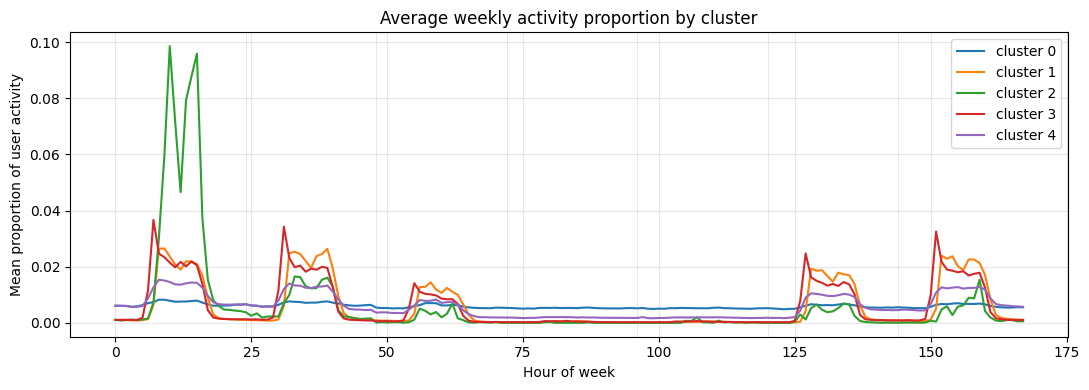

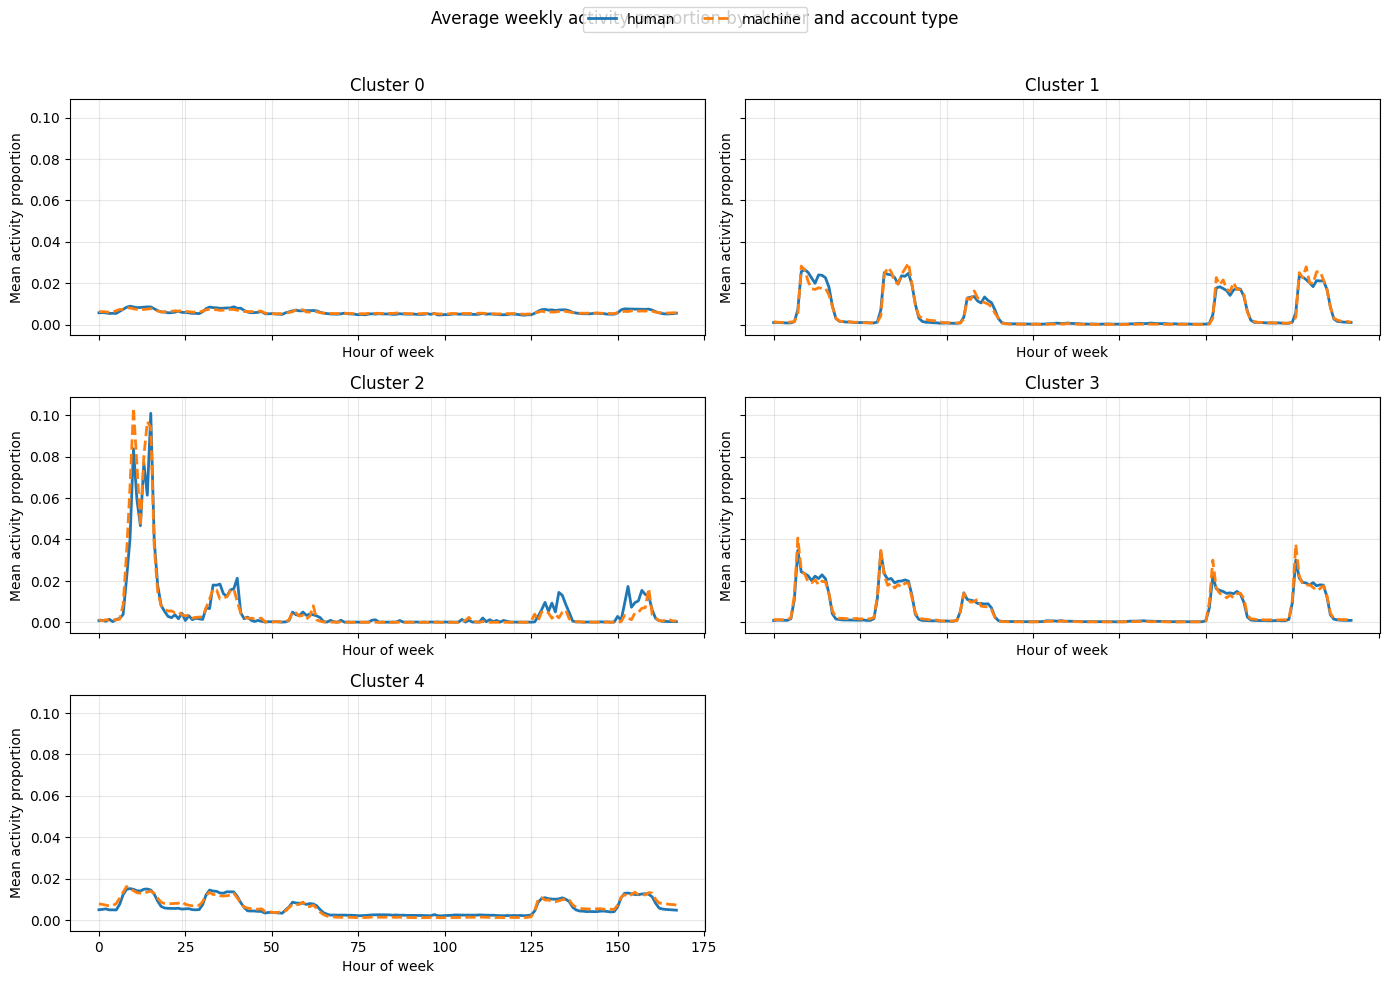


Quartile summary by cluster and account type
    cluster type_str  quantile  top1_hour_share  top10_hour_share  \
0         0    human      0.25           0.0140            0.1148   
1         0    human      0.50           0.0171            0.1331   
2         0    human      0.75           0.0225            0.1571   
3         0  machine      0.25           0.0118            0.0931   
4         0  machine      0.50           0.0141            0.1024   
5         0  machine      0.75           0.0184            0.1205   
6         1    human      0.25           0.0408            0.3142   
7         1    human      0.50           0.0535            0.3710   
8         1    human      0.75           0.0830            0.5120   
9         1  machine      0.25           0.0573            0.3655   
10        1  machine      0.50           0.0952            0.5161   
11        1  machine      0.75           0.2371            0.8812   
12        2    human      0.25           0.1381          

12

In [6]:
import gc
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# ============================================================
# Settings
# ============================================================
TIME_COL = "time"
USER_COL = "source_user@domain"
TYPE_COL = "source_user_type"

BASE_MIN_EVENTS = 500
USE_STRICT_GREATER_THAN = True   # True means n_events > 500; False means n_events >= 500

N_CLUSTERS = 5
RANDOM_STATE = 42

US_PER_HOUR = 60 * 60 * 1_000_000
N_HOURS_WEEK = 168

DAY_START = 6
NIGHT_START = 20

pl.Config.set_tbl_rows(120)
pl.Config.set_tbl_cols(40)
pl.Config.set_fmt_str_lengths(100)

def collect_streaming(lf):
    try:
        return lf.collect(engine="streaming")
    except TypeError:
        return lf.collect(streaming=True)

# ============================================================
# 1. Build base user list
# ============================================================
base_user_counts = collect_streaming(
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str")
      ])
      .filter(pl.col("type_str").is_in(["human", "machine"]))
      .group_by([USER_COL, "type_str"])
      .agg(pl.len().alias("n_events"))
)

if USE_STRICT_GREATER_THAN:
    base_users = base_user_counts.filter(pl.col("n_events") > BASE_MIN_EVENTS)
else:
    base_users = base_user_counts.filter(pl.col("n_events") >= BASE_MIN_EVENTS)

print("Base users:")
print(
    base_users
    .group_by("type_str")
    .agg([
        pl.len().alias("n_accounts"),
        pl.col("n_events").sum().alias("n_events"),
        pl.col("n_events").median().alias("events_p50"),
    ])
    .sort("type_str")
)

# ============================================================
# 2. Build user × hour-of-week counts
# ============================================================
min_us = df.select(pl.col(TIME_COL).cast(pl.Int64).min()).item()

hour_idx = ((pl.col(TIME_COL).cast(pl.Int64) - min_us) // US_PER_HOUR).cast(pl.Int64)
day_idx = (hour_idx // 24).cast(pl.Int64)
hour_of_day = (hour_idx % 24).cast(pl.Int64)
day_of_week = (day_idx % 7).cast(pl.Int64)
hour_of_week = (day_of_week * 24 + hour_of_day).cast(pl.Int64)

user_hour = collect_streaming(
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str")
      ])
      .filter(pl.col("type_str").is_in(["human", "machine"]))
      .join(
          base_users.select([USER_COL, "type_str"]).lazy(),
          on=[USER_COL, "type_str"],
          how="inner"
      )
      .select([
          pl.col(USER_COL),
          pl.col("type_str"),
          hour_of_week.alias("hour_of_week"),
      ])
      .group_by([USER_COL, "type_str", "hour_of_week"])
      .agg(pl.len().alias("cell_events"))
)

# ============================================================
# 3. Convert counts into weekly proportion vectors
# ============================================================
# Each user's vector is:
# p_h = events in hour h / total events for that user
# Therefore each row sums to 1.

user_totals = (
    user_hour
    .group_by([USER_COL, "type_str"])
    .agg(pl.col("cell_events").sum().alias("n_events"))
)

profile_df = (
    user_hour
    .join(user_totals, on=[USER_COL, "type_str"], how="inner")
    .with_columns([
        (pl.col("cell_events") / pl.col("n_events")).alias("p")
    ])
    .select([USER_COL, "type_str", "hour_of_week", "p"])
)

profile_pd = profile_df.to_pandas()

profile_wide = (
    profile_pd
    .pivot_table(
        index=[USER_COL, "type_str"],
        columns="hour_of_week",
        values="p",
        fill_value=0.0,
        aggfunc="sum",
    )
)

# Ensure all 168 hour columns exist
for h in range(N_HOURS_WEEK):
    if h not in profile_wide.columns:
        profile_wide[h] = 0.0

hour_cols = list(range(N_HOURS_WEEK))
profile_wide = profile_wide[hour_cols]

# Matrix used for clustering.
# No L2 normalisation is applied.
X = profile_wide.to_numpy()

# Sanity check: each user's profile should sum to 1
row_sums = X.sum(axis=1)
print("\nProfile row-sum check:")
print(pd.Series(row_sums).describe())

# ============================================================
# 4. K-means clustering on weekly proportion profiles
# ============================================================
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
)

cluster_labels = kmeans.fit_predict(X)

cluster_members = (
    profile_wide
    .reset_index()[[USER_COL, "type_str"]]
    .assign(cluster=cluster_labels)
)

cluster_pl = pl.from_pandas(cluster_members)

# ============================================================
# 5. Cluster summary
# ============================================================
cluster_summary = (
    cluster_pl
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .group_by("cluster")
    .agg([
        pl.len().alias("n_accounts"),
        (pl.col("type_str") == "human").sum().alias("n_human"),
        (pl.col("type_str") == "machine").sum().alias("n_machine"),
        pl.col("n_events").sum().alias("n_events"),
        pl.col("n_events").median().alias("events_p50"),
        pl.col("n_events").quantile(0.90).alias("events_p90"),
    ])
    .with_columns([
        (pl.col("n_human") / pl.col("n_accounts")).alias("human_share"),
        (pl.col("n_machine") / pl.col("n_accounts")).alias("machine_share"),
    ])
    .sort("n_accounts", descending=True)
)

print("\nCluster summary:")
print(cluster_summary)

# ============================================================
# 6. Interpretable average cluster profiles
# ============================================================
# These are mean proportion profiles.
# Each cluster average should sum to approximately 1.

cluster_profile_prop = (
    pd.DataFrame(X, index=profile_wide.index, columns=hour_cols)
    .assign(cluster=cluster_labels)
    .groupby("cluster")
    .mean()
)

print("\nCluster profile sum check:")
print(cluster_profile_prop.sum(axis=1))

fig, ax = plt.subplots(figsize=(11, 4))

for cluster in cluster_profile_prop.index:
    ax.plot(
        hour_cols,
        cluster_profile_prop.loc[cluster],
        label=f"cluster {cluster}"
    )

ax.set_title("Average weekly activity proportion by cluster")
ax.set_xlabel("Hour of week")
ax.set_ylabel("Mean proportion of user activity")
ax.grid(True, alpha=0.3)

for x in range(24, N_HOURS_WEEK, 24):
    ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. Dense user profiles with cluster labels
# ============================================================
dense_profiles = (
    pd.DataFrame(X, index=profile_wide.index, columns=hour_cols)
    .reset_index()
)

dense_profiles["cluster"] = cluster_labels

# ============================================================
# 8. Small-multiples plot: cluster × account type
# ============================================================
# One subplot per cluster.
# Human and machine are plotted on the same axis for that cluster.

cluster_type_profile_dense = (
    dense_profiles
    .groupby(["cluster", "type_str"])[hour_cols]
    .mean()
    .reset_index()
)

clusters = sorted(cluster_type_profile_dense["cluster"].unique())

n_cols = 2
n_rows = int(np.ceil(len(clusters) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.2 * n_rows),
    sharex=True,
    sharey=True,
)

axes = np.array(axes).reshape(-1)

type_colours = {
    "human": "tab:blue",
    "machine": "tab:orange",
}

type_linestyles = {
    "human": "-",
    "machine": "--",
}

for ax, cluster in zip(axes, clusters):
    sub = cluster_type_profile_dense[
        cluster_type_profile_dense["cluster"] == cluster
    ]

    for type_str in ["human", "machine"]:
        row = sub[sub["type_str"] == type_str]

        if row.empty:
            continue

        y = row[hour_cols].iloc[0].to_numpy()

        ax.plot(
            hour_cols,
            y,
            color=type_colours[type_str],
            linestyle=type_linestyles[type_str],
            linewidth=2,
            label=type_str,
        )

    ax.set_title(f"Cluster {cluster}")
    ax.grid(True, alpha=0.3)

    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

    ax.set_xlabel("Hour of week")
    ax.set_ylabel("Mean activity proportion")

# Hide unused axes
for ax in axes[len(clusters):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Average weekly activity proportion by cluster and account type", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 9. User-level activity-shape metrics
# ============================================================
P = dense_profiles[hour_cols].to_numpy()

dense_profiles["top1_hour_share"] = P.max(axis=1)
dense_profiles["top10_hour_share"] = np.sort(P, axis=1)[:, -10:].sum(axis=1)
dense_profiles["coverage_168"] = (P > 0).sum(axis=1) / N_HOURS_WEEK

P_safe = np.where(P > 0, P, 1.0)
dense_profiles["entropy_norm"] = -np.sum(
    np.where(P > 0, P * np.log(P_safe), 0.0),
    axis=1
) / np.log(N_HOURS_WEEK)

daytime_hours = [
    h for h in hour_cols
    if DAY_START <= (h % 24) < NIGHT_START
]

night_hours = [
    h for h in hour_cols
    if not (DAY_START <= (h % 24) < NIGHT_START)
]

dense_profiles["daytime_share"] = dense_profiles[daytime_hours].sum(axis=1)
dense_profiles["night_share"] = dense_profiles[night_hours].sum(axis=1)

# ============================================================
# 10. Quartile summary by cluster and account type
# ============================================================
metrics = [
    "top1_hour_share",
    "top10_hour_share",
    "coverage_168",
    "entropy_norm",
    "daytime_share",
    "night_share",
]

quartile_summary = (
    dense_profiles
    .groupby(["cluster", "type_str"])[metrics]
    .quantile([0.25, 0.50, 0.75])
    .reset_index()
)

# Rename the quantile column robustly
non_metric_cols = [c for c in quartile_summary.columns if c not in ["cluster", "type_str"] + metrics]
if len(non_metric_cols) == 1:
    quartile_summary = quartile_summary.rename(columns={non_metric_cols[0]: "quantile"})

quartile_summary = quartile_summary.sort_values(["cluster", "type_str", "quantile"])

print("\nQuartile summary by cluster and account type")
print(quartile_summary.round(4))

# ============================================================
# 11. Median-only summary for quick reading
# ============================================================
median_summary = (
    dense_profiles
    .groupby(["cluster", "type_str"])[metrics]
    .median()
    .reset_index()
    .sort_values(["cluster", "type_str"])
)

print("\nMedian summary by cluster and account type")
print(median_summary.round(4))

# ============================================================
# 12. Saved outputs
# ============================================================
print("\nSaved useful objects:")
print("- user_hour")
print("- user_totals")
print("- profile_df")
print("- profile_wide")
print("- cluster_members")
print("- cluster_pl")
print("- cluster_summary")
print("- cluster_profile_prop")
print("- dense_profiles")
print("- cluster_type_profile_dense")
print("- quartile_summary")
print("- median_summary")

gc.collect()

In [9]:
# ============================================================
# Volume diagnostics after clustering
# ============================================================
# Purpose:
# - Clustering used temporal shape only.
# - This summarises event volume by cluster and account type.

import pandas as pd
import numpy as np

# Join cluster labels to event counts
volume_by_cluster_type = (
    cluster_pl
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .to_pandas()
)

# ============================================================
# 1. Event-count quartiles by cluster and account type
# ============================================================

count_iqr_summary = (
    volume_by_cluster_type
    .groupby(["cluster", "type_str"])["n_events"]
    .agg(
        n_accounts="count",
        events_total="sum",
        events_q25=lambda x: x.quantile(0.25),
        events_median="median",
        events_q75=lambda x: x.quantile(0.75),
        events_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        events_p90=lambda x: x.quantile(0.90),
        events_p99=lambda x: x.quantile(0.99),
        events_max="max",
    )
    .reset_index()
    .sort_values(["cluster", "type_str"])
)

print("\nEvent-count IQR summary by cluster and account type")
print(count_iqr_summary.round(1))

# ============================================================
# 2. Event-count quartiles by cluster only
# ============================================================

count_iqr_cluster_summary = (
    volume_by_cluster_type
    .groupby("cluster")["n_events"]
    .agg(
        n_accounts="count",
        events_total="sum",
        events_q25=lambda x: x.quantile(0.25),
        events_median="median",
        events_q75=lambda x: x.quantile(0.75),
        events_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        events_p90=lambda x: x.quantile(0.90),
        events_p99=lambda x: x.quantile(0.99),
        events_max="max",
    )
    .reset_index()
    .sort_values("cluster")
)

print("\nEvent-count IQR summary by cluster")
print(count_iqr_cluster_summary.round(1))

# ============================================================
# 3. Shares of accounts and events by cluster/type
# ============================================================

cluster_type_shares = (
    volume_by_cluster_type
    .groupby(["cluster", "type_str"])
    .agg(
        n_accounts=("n_events", "count"),
        events_total=("n_events", "sum"),
    )
    .reset_index()
)

cluster_type_shares["account_share_overall"] = (
    cluster_type_shares["n_accounts"] / cluster_type_shares["n_accounts"].sum()
)

cluster_type_shares["event_share_overall"] = (
    cluster_type_shares["events_total"] / cluster_type_shares["events_total"].sum()
)

cluster_type_shares["account_share_within_type"] = (
    cluster_type_shares["n_accounts"] /
    cluster_type_shares.groupby("type_str")["n_accounts"].transform("sum")
)

cluster_type_shares["event_share_within_type"] = (
    cluster_type_shares["events_total"] /
    cluster_type_shares.groupby("type_str")["events_total"].transform("sum")
)

print("\nAccount/event shares by cluster and account type")
print(cluster_type_shares.round(4).sort_values(["cluster", "type_str"]))


Event-count IQR summary by cluster and account type
   cluster type_str  n_accounts  events_total  events_q25  events_median  \
0        0    human        3413     133204909      9111.0        14075.0   
1        0  machine        9109     346231748     22472.0        26945.0   
2        1    human        1679      14561947      1389.0         5442.0   
3        1  machine         813       4435677      1418.0         4112.0   
4        2    human          47        117093       669.0          970.0   
5        2  machine         137        190131       763.0          973.0   
6        3    human        1484      12384771      3636.5         6943.5   
7        3  machine         718       6429153      6565.5         9459.5   
8        4    human        3045      51167699      8266.0        13371.0   
9        4  machine        1971      30448545      7974.5        14502.0   

   events_q75  events_iqr  events_p90  events_p99  events_max  
0     22774.0     13663.0     58431.0    36587

In [ ]:
# ============================================================
# Plot 5 example human accounts from cluster 1
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

EXAMPLE_CLUSTER = 0
N_EXAMPLES = 5

# ------------------------------------------------------------
# 1. Select 5 human accounts from cluster 1
# ------------------------------------------------------------
cluster1_humans = (
    cluster_pl
    .filter(
        (pl.col("cluster") == EXAMPLE_CLUSTER) &
        (pl.col("type_str") == "human")
    )
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .sort("n_events", descending=True)
)

# Take a spread across volumes rather than just the largest 5
cluster1_humans_pd = cluster1_humans.to_pandas()

idx = np.linspace(
    0,
    len(cluster1_humans_pd) - 1,
    N_EXAMPLES
).round().astype(int)

example_users = cluster1_humans_pd.iloc[idx][[USER_COL, "type_str", "cluster", "n_events"]]

print("\nExample human accounts from cluster 1")
print(example_users)

example_user_list = example_users[USER_COL].tolist()

# ------------------------------------------------------------
# 2. Build hourly time series for those users
# ------------------------------------------------------------
min_us = df.select(pl.col(TIME_COL).cast(pl.Int64).min()).item()

hour_idx = ((pl.col(TIME_COL).cast(pl.Int64) - min_us) // US_PER_HOUR).cast(pl.Int64)

example_ts = (
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str"),
          hour_idx.alias("hour_idx"),
      ])
      .filter(
          (pl.col("type_str") == "human") &
          (pl.col(USER_COL).is_in(example_user_list))
      )
      .group_by([USER_COL, "hour_idx"])
      .agg(pl.len().alias("count"))
      .collect()
)

# Dense grid so missing hours appear as zero
max_hour = example_ts.select(pl.col("hour_idx").max()).item()

all_hours = pl.DataFrame({"hour_idx": list(range(max_hour + 1))})
all_users = pl.DataFrame({USER_COL: example_user_list})

dense_grid = all_users.join(all_hours, how="cross")

example_ts_dense = (
    dense_grid
    .join(example_ts, on=[USER_COL, "hour_idx"], how="left")
    .with_columns([
        pl.col("count").fill_null(0)
    ])
    .sort([USER_COL, "hour_idx"])
)

# ------------------------------------------------------------
# 3. Plot one subplot per account
# ------------------------------------------------------------
example_ts_pd = example_ts_dense.to_pandas()

fig, axes = plt.subplots(
    N_EXAMPLES,
    1,
    figsize=(12, 2.2 * N_EXAMPLES),
    sharex=True
)

if N_EXAMPLES == 1:
    axes = [axes]

for ax, user in zip(axes, example_user_list):
    sub = example_ts_pd[example_ts_pd[USER_COL] == user]

    n_events = example_users.loc[
        example_users[USER_COL] == user,
        "n_events"
    ].iloc[0]

    ax.plot(sub["hour_idx"], sub["count"], linewidth=1)

    ax.set_title(f"{user} | cluster {EXAMPLE_CLUSTER} | n_events={n_events:,.0f}")
    ax.set_ylabel("Hourly count")
    ax.grid(True, alpha=0.3)

    # Optional weekly separators
    for x in range(168, int(max_hour) + 1, 168):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

axes[-1].set_xlabel("Hour since start of observation window")

plt.tight_layout()
plt.show()


Example human accounts from cluster 1
     source_user@domain type_str  cluster  n_events
0            C599$@DOM1  machine        0   5659956
2277       C12753$@DOM1  machine        0     32135
4554        C6853$@DOM1  machine        0     26945
6831       C12850$@DOM1  machine        0     22472
9108        C5673$@DOM1  machine        0       517


TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'

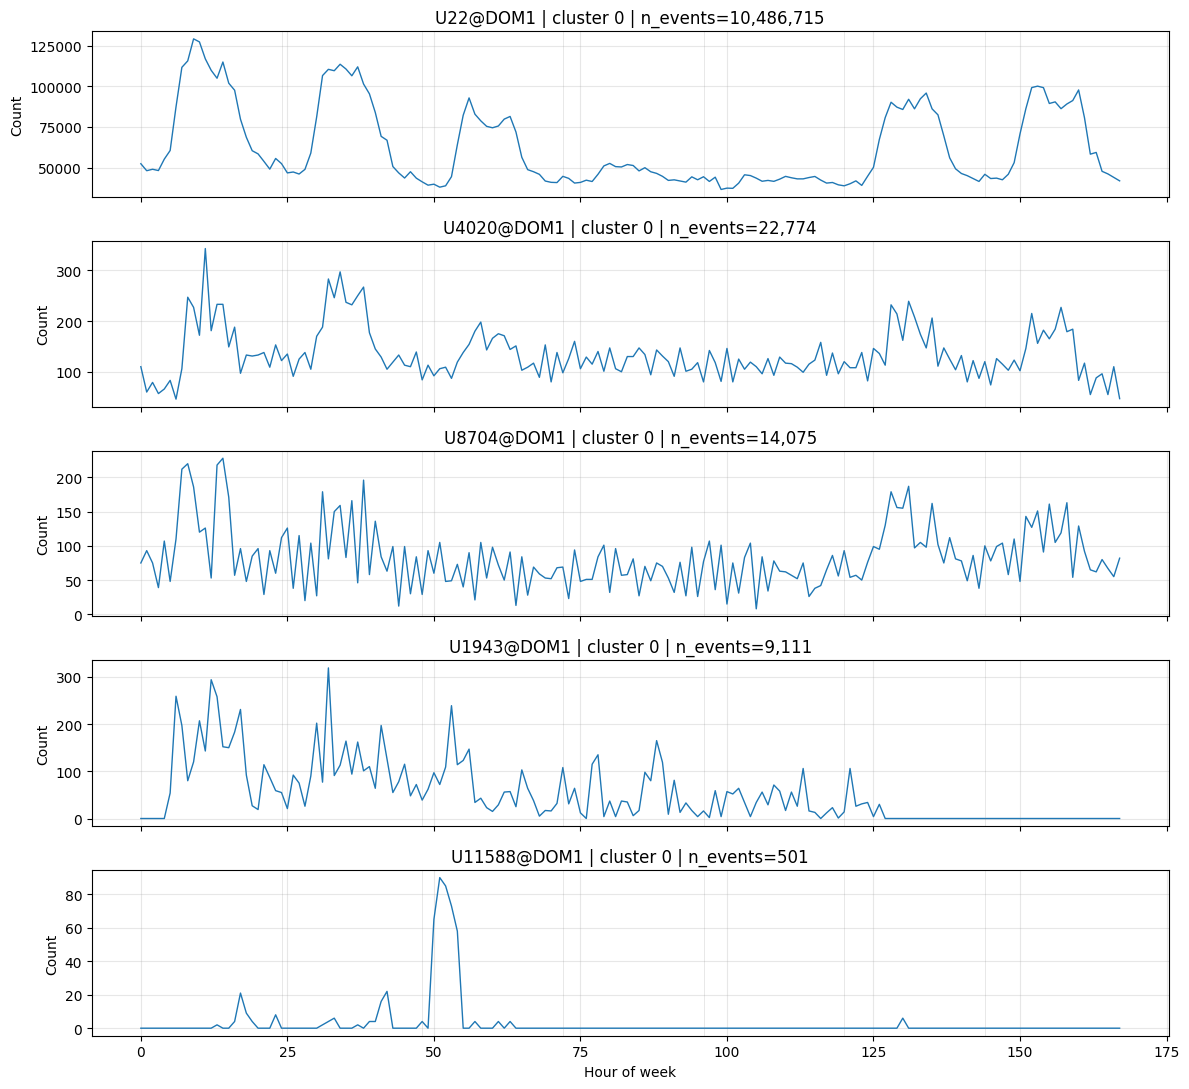

In [14]:
# ============================================================
# Plot hour-of-week profiles for the selected example users
# ============================================================

# Aggregate selected users by hour of week
example_how = (
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str"),
          hour_of_week.alias("hour_of_week"),
      ])
      .filter(
          (pl.col("type_str") == "human") &
          (pl.col(USER_COL).is_in(example_user_list))
      )
      .group_by([USER_COL, "hour_of_week"])
      .agg(pl.len().alias("count"))
      .collect()
)

# Dense user × hour-of-week grid
all_hours_week = pl.DataFrame({"hour_of_week": list(range(N_HOURS_WEEK))})
all_users = pl.DataFrame({USER_COL: example_user_list})

dense_how_grid = all_users.join(all_hours_week, how="cross")

example_how_dense = (
    dense_how_grid
    .join(example_how, on=[USER_COL, "hour_of_week"], how="left")
    .with_columns([
        pl.col("count").fill_null(0)
    ])
    .sort([USER_COL, "hour_of_week"])
)

example_how_pd = example_how_dense.to_pandas()

# Plot raw hour-of-week counts
fig, axes = plt.subplots(
    N_EXAMPLES,
    1,
    figsize=(12, 2.2 * N_EXAMPLES),
    sharex=True
)

if N_EXAMPLES == 1:
    axes = [axes]

for ax, user in zip(axes, example_user_list):
    sub = example_how_pd[example_how_pd[USER_COL] == user]

    n_events = example_users.loc[
        example_users[USER_COL] == user,
        "n_events"
    ].iloc[0]

    ax.plot(sub["hour_of_week"], sub["count"], linewidth=1)

    ax.set_title(f"{user} | cluster {EXAMPLE_CLUSTER} | n_events={n_events:,.0f}")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

axes[-1].set_xlabel("Hour of week")

plt.tight_layout()
plt.show()


Matching users:
hour_of_week source_user@domain type_str  cluster
14630                  U22@DOM1    human        0

Target user: U22@DOM1
Type: human
Assigned cluster: 0

Distance to cluster centroids:
   cluster  distance_to_centroid  assigned_cluster
0        0              0.020907              True
1        4              0.027056             False
2        3              0.081275             False
3        1              0.083283             False
4        2              0.191359             False


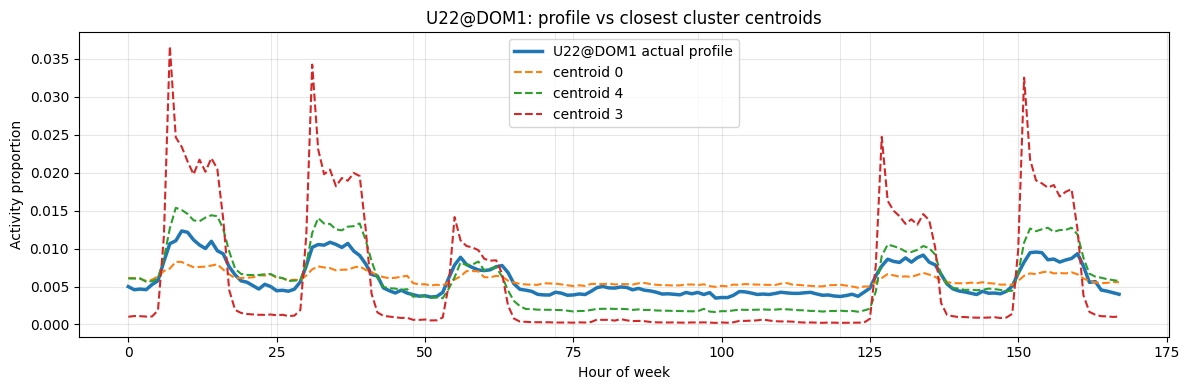

In [15]:
# ============================================================
# Distance of one user to all cluster centroids
# ============================================================

TARGET_USER = "U22@DOM1"

# 1. Check exact match
matches = cluster_members[
    cluster_members[USER_COL].str.upper() == TARGET_USER.upper()
].copy()

print("\nMatching users:")
print(matches)

if matches.empty:
    raise ValueError(f"No user matching {TARGET_USER} found in cluster_members")

# Use the first exact/case-insensitive match
target_user = matches.iloc[0][USER_COL]
target_type = matches.iloc[0]["type_str"]
assigned_cluster = matches.iloc[0]["cluster"]

# 2. Pull that user's 168-hour proportion vector
target_vector = profile_wide.loc[(target_user, target_type)].to_numpy().reshape(1, -1)

# 3. Compute Euclidean distance to each K-means centroid
centroids = kmeans.cluster_centers_

distances = np.linalg.norm(centroids - target_vector, axis=1)

distance_df = (
    pd.DataFrame({
        "cluster": np.arange(len(distances)),
        "distance_to_centroid": distances,
    })
    .sort_values("distance_to_centroid")
    .reset_index(drop=True)
)

distance_df["assigned_cluster"] = distance_df["cluster"] == assigned_cluster

print(f"\nTarget user: {target_user}")
print(f"Type: {target_type}")
print(f"Assigned cluster: {assigned_cluster}")

print("\nDistance to cluster centroids:")
print(distance_df.round(6))

# 4. Optional: compare target profile visually with closest centroids
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    range(N_HOURS_WEEK),
    target_vector.flatten(),
    linewidth=2.5,
    label=f"{target_user} actual profile",
)

for cluster in distance_df["cluster"].head(3):
    ax.plot(
        range(N_HOURS_WEEK),
        centroids[cluster],
        linewidth=1.5,
        linestyle="--",
        label=f"centroid {cluster}",
    )

ax.set_title(f"{target_user}: profile vs closest cluster centroids")
ax.set_xlabel("Hour of week")
ax.set_ylabel("Activity proportion")
ax.grid(True, alpha=0.3)

for x in range(24, N_HOURS_WEEK, 24):
    ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

ax.legend()
plt.tight_layout()
plt.show()

Reference user: U22@DOM1
Reference type: human
Reference cluster: 0

Example machine accounts from cluster 0
     source_user@domain type_str  cluster  n_events
0            C599$@DOM1  machine        0   5659956
2277       C12753$@DOM1  machine        0     32135
4554        C6853$@DOM1  machine        0     26945
6831       C12850$@DOM1  machine        0     22472
9108        C5673$@DOM1  machine        0       517


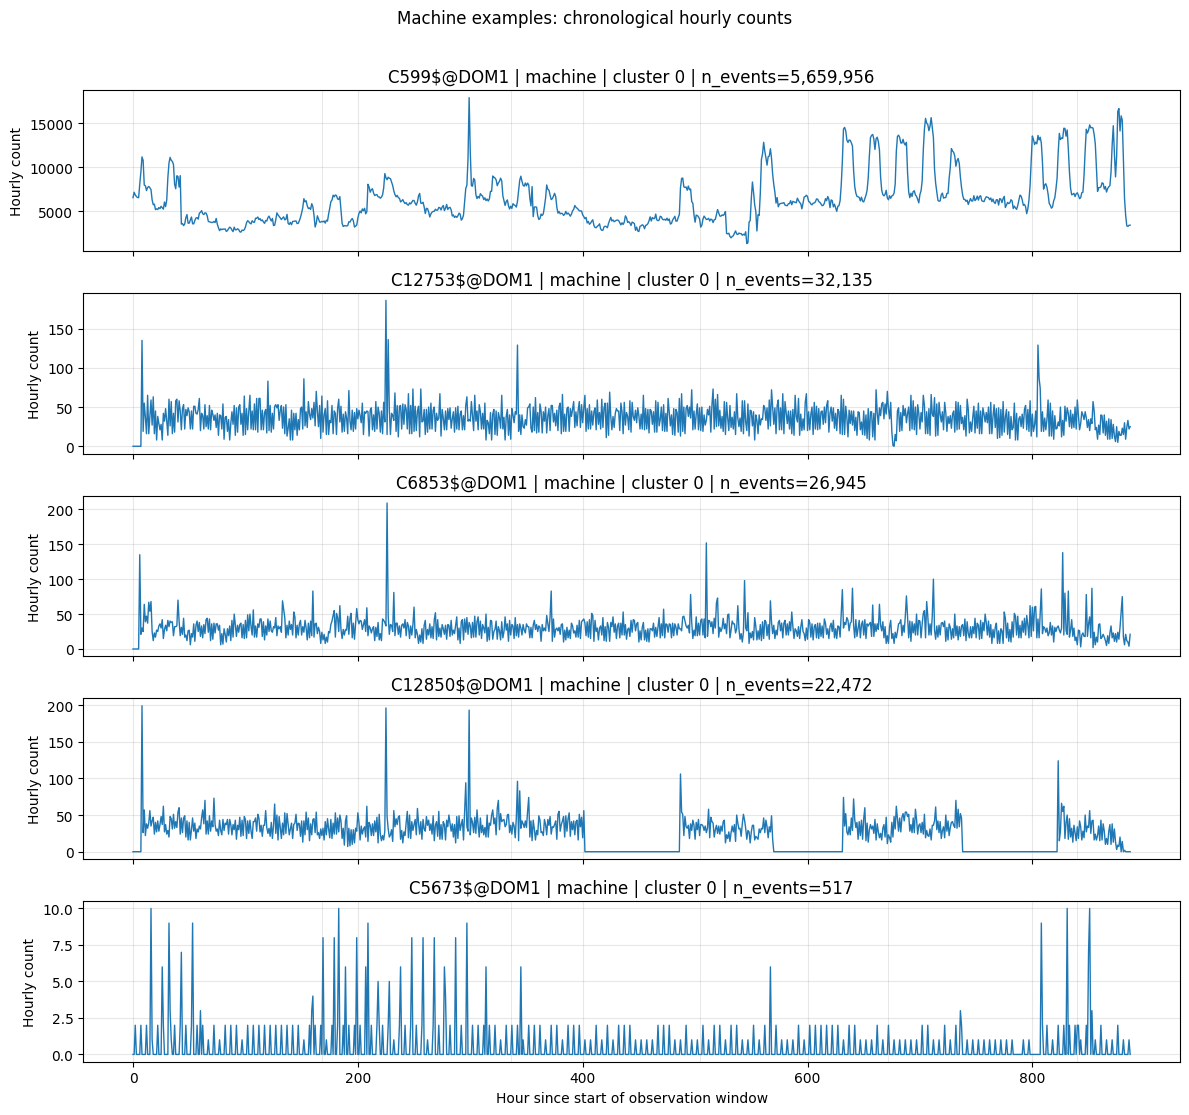

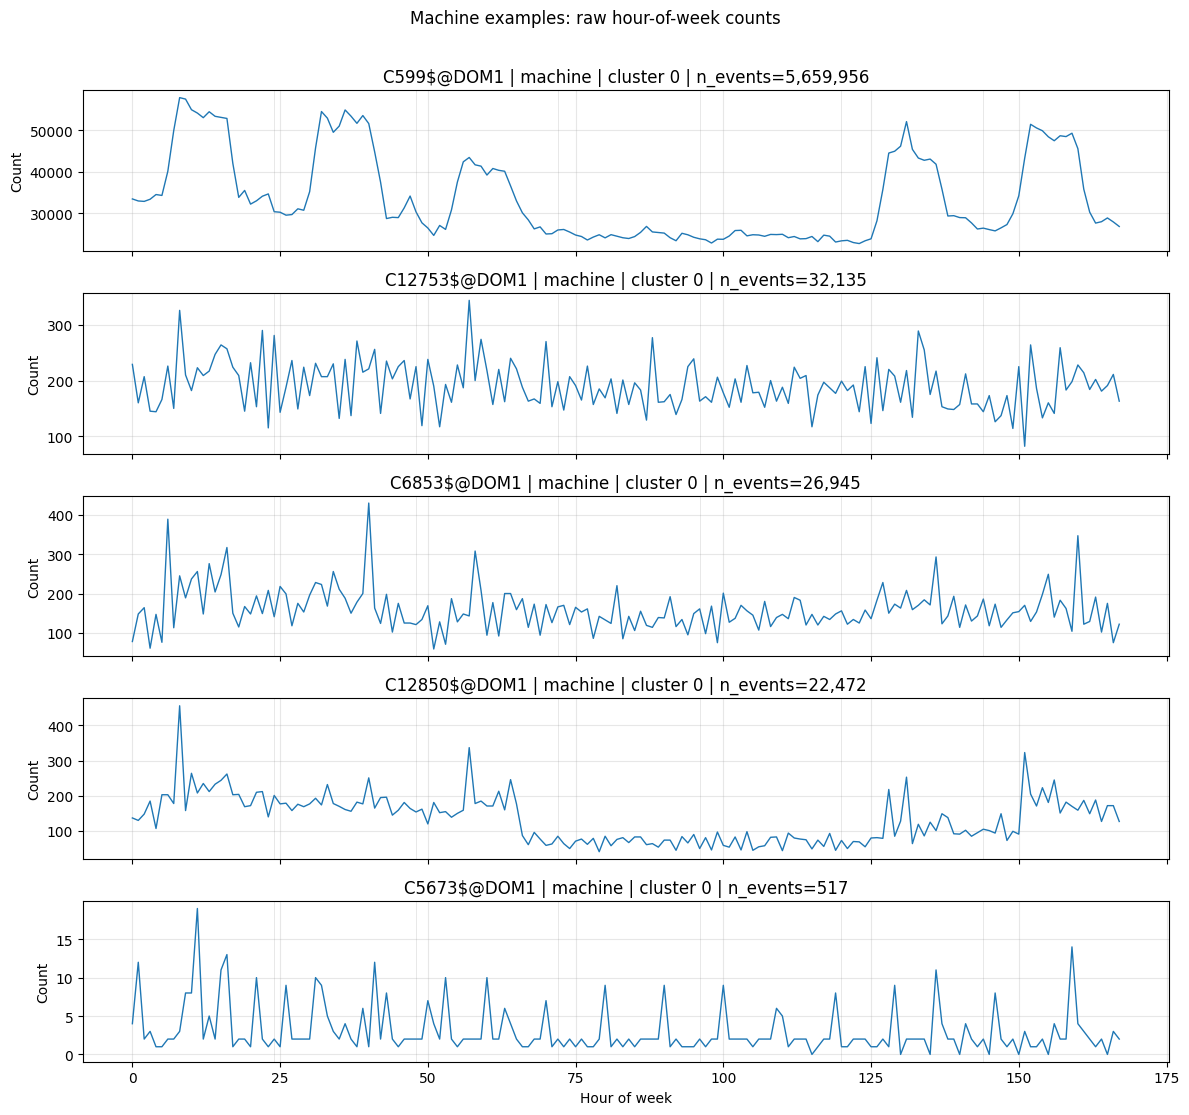

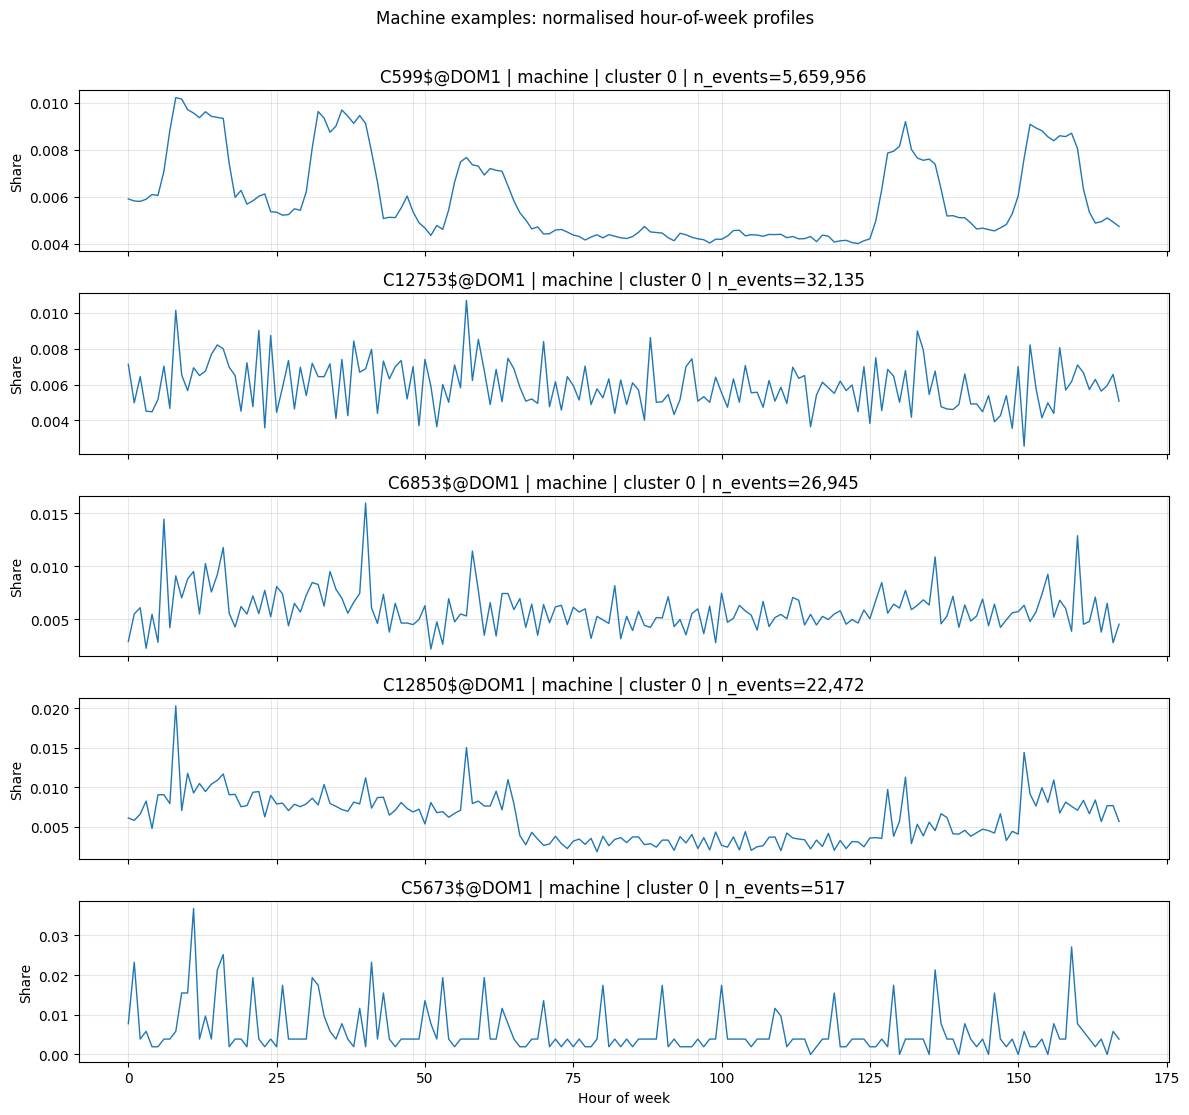

In [17]:
# ============================================================
# Pick 5 machine examples from the same cluster and plot
# chronological + hour-of-week profiles
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

REFERENCE_USER = "U22@DOM1"
N_EXAMPLES = 5

# ------------------------------------------------------------
# 1. Find reference user's assigned cluster
# ------------------------------------------------------------
reference_match = cluster_members[
    cluster_members[USER_COL].str.upper() == REFERENCE_USER.upper()
].copy()

if reference_match.empty:
    raise ValueError(f"No user matching {REFERENCE_USER} found in cluster_members")

reference_user = reference_match.iloc[0][USER_COL]
reference_type = reference_match.iloc[0]["type_str"]
reference_cluster = int(reference_match.iloc[0]["cluster"])

print(f"Reference user: {reference_user}")
print(f"Reference type: {reference_type}")
print(f"Reference cluster: {reference_cluster}")

# ------------------------------------------------------------
# 2. Select 5 machine accounts from same cluster
# ------------------------------------------------------------
same_cluster_machines = (
    cluster_pl
    .filter(
        (pl.col("cluster") == reference_cluster) &
        (pl.col("type_str") == "machine")
    )
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .sort("n_events", descending=True)
)

same_cluster_machines_pd = same_cluster_machines.to_pandas()

if len(same_cluster_machines_pd) < N_EXAMPLES:
    raise ValueError(
        f"Only {len(same_cluster_machines_pd)} machine accounts found in cluster {reference_cluster}"
    )

# Select spread across volume distribution, not just top 5
idx = np.linspace(
    0,
    len(same_cluster_machines_pd) - 1,
    N_EXAMPLES
).round().astype(int)

example_machines = same_cluster_machines_pd.iloc[idx][
    [USER_COL, "type_str", "cluster", "n_events"]
]

print(f"\nExample machine accounts from cluster {reference_cluster}")
print(example_machines)

example_machine_list = example_machines[USER_COL].tolist()

# ------------------------------------------------------------
# 3. Build chronological hourly time series
# ------------------------------------------------------------
min_us = df.select(pl.col(TIME_COL).cast(pl.Int64).min()).item()

hour_idx_expr = ((pl.col(TIME_COL).cast(pl.Int64) - min_us) // US_PER_HOUR).cast(pl.Int64)

machine_ts = (
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str"),
          hour_idx_expr.alias("hour_idx"),
      ])
      .filter(
          (pl.col("type_str") == "machine") &
          (pl.col(USER_COL).is_in(example_machine_list))
      )
      .group_by([USER_COL, "hour_idx"])
      .agg(pl.len().alias("count"))
      .collect()
)

max_hour = machine_ts.select(pl.col("hour_idx").max()).item()

all_hours = pl.DataFrame({"hour_idx": list(range(max_hour + 1))})
all_users = pl.DataFrame({USER_COL: example_machine_list})

dense_grid = all_users.join(all_hours, how="cross")

machine_ts_dense = (
    dense_grid
    .join(machine_ts, on=[USER_COL, "hour_idx"], how="left")
    .with_columns([
        pl.col("count").fill_null(0)
    ])
    .sort([USER_COL, "hour_idx"])
)

machine_ts_pd = machine_ts_dense.to_pandas()

# ------------------------------------------------------------
# 4. Plot chronological hourly time series
# ------------------------------------------------------------
fig, axes = plt.subplots(
    N_EXAMPLES,
    1,
    figsize=(12, 2.2 * N_EXAMPLES),
    sharex=True
)

if N_EXAMPLES == 1:
    axes = [axes]

for ax, user in zip(axes, example_machine_list):
    sub = machine_ts_pd[machine_ts_pd[USER_COL] == user]

    n_events = example_machines.loc[
        example_machines[USER_COL] == user,
        "n_events"
    ].iloc[0]

    ax.plot(sub["hour_idx"], sub["count"], linewidth=1)

    ax.set_title(f"{user} | machine | cluster {reference_cluster} | n_events={n_events:,.0f}")
    ax.set_ylabel("Hourly count")
    ax.grid(True, alpha=0.3)

    for x in range(168, int(max_hour) + 1, 168):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

axes[-1].set_xlabel("Hour since start of observation window")
fig.suptitle("Machine examples: chronological hourly counts", y=1.01)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Build hour-of-week profiles
# ------------------------------------------------------------
hour_idx = ((pl.col(TIME_COL).cast(pl.Int64) - min_us) // US_PER_HOUR).cast(pl.Int64)
day_idx = (hour_idx // 24).cast(pl.Int64)
hour_of_day = (hour_idx % 24).cast(pl.Int64)
day_of_week = (day_idx % 7).cast(pl.Int64)
hour_of_week_expr = (day_of_week * 24 + hour_of_day).cast(pl.Int64)

machine_how = (
    df.lazy()
      .with_columns([
          pl.col(TYPE_COL).cast(pl.Utf8).alias("type_str"),
          hour_of_week_expr.alias("hour_of_week"),
      ])
      .filter(
          (pl.col("type_str") == "machine") &
          (pl.col(USER_COL).is_in(example_machine_list))
      )
      .group_by([USER_COL, "hour_of_week"])
      .agg(pl.len().alias("count"))
      .collect()
)

all_hours_week = pl.DataFrame({"hour_of_week": list(range(N_HOURS_WEEK))})
all_users = pl.DataFrame({USER_COL: example_machine_list})

dense_how_grid = all_users.join(all_hours_week, how="cross")

machine_how_dense = (
    dense_how_grid
    .join(machine_how, on=[USER_COL, "hour_of_week"], how="left")
    .with_columns([
        pl.col("count").fill_null(0)
    ])
    .sort([USER_COL, "hour_of_week"])
)

machine_how_pd = machine_how_dense.to_pandas()

# ------------------------------------------------------------
# 6. Plot raw hour-of-week counts
# ------------------------------------------------------------
fig, axes = plt.subplots(
    N_EXAMPLES,
    1,
    figsize=(12, 2.2 * N_EXAMPLES),
    sharex=True
)

if N_EXAMPLES == 1:
    axes = [axes]

for ax, user in zip(axes, example_machine_list):
    sub = machine_how_pd[machine_how_pd[USER_COL] == user]

    n_events = example_machines.loc[
        example_machines[USER_COL] == user,
        "n_events"
    ].iloc[0]

    ax.plot(sub["hour_of_week"], sub["count"], linewidth=1)

    ax.set_title(f"{user} | machine | cluster {reference_cluster} | n_events={n_events:,.0f}")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

axes[-1].set_xlabel("Hour of week")
fig.suptitle("Machine examples: raw hour-of-week counts", y=1.01)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Plot normalised hour-of-week profiles
# ------------------------------------------------------------
machine_how_norm = (
    machine_how_dense
    .join(
        machine_how_dense
        .group_by(USER_COL)
        .agg(pl.col("count").sum().alias("total_count")),
        on=USER_COL,
        how="left"
    )
    .with_columns([
        (pl.col("count") / pl.col("total_count")).alias("p")
    ])
)

machine_how_norm_pd = machine_how_norm.to_pandas()

fig, axes = plt.subplots(
    N_EXAMPLES,
    1,
    figsize=(12, 2.2 * N_EXAMPLES),
    sharex=True
)

if N_EXAMPLES == 1:
    axes = [axes]

for ax, user in zip(axes, example_machine_list):
    sub = machine_how_norm_pd[machine_how_norm_pd[USER_COL] == user]

    n_events = example_machines.loc[
        example_machines[USER_COL] == user,
        "n_events"
    ].iloc[0]

    ax.plot(sub["hour_of_week"], sub["p"], linewidth=1)

    ax.set_title(f"{user} | machine | cluster {reference_cluster} | n_events={n_events:,.0f}")
    ax.set_ylabel("Share")
    ax.grid(True, alpha=0.3)

    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

axes[-1].set_xlabel("Hour of week")
fig.suptitle("Machine examples: normalised hour-of-week profiles", y=1.01)
plt.tight_layout()
plt.show()


GMM converged: True
GMM iterations: 34
GMM lower bound: 753.254503
GMM AIC: -33766497.33
GMM BIC: -33752995.81

K-means vs GMM agreement
Adjusted Rand Index: 0.5729
Normalised Mutual Information: 0.5024

K-means vs GMM counts
GMM cluster          0     1     2    3     4
K-means cluster                              
0                10038  1907     5  568     4
1                    0   117  1538  153   684
2                    0     0   120   22    42
3                    0   163  1335   78   626
4                   15  3000    15  266  1720

K-means vs GMM row shares
GMM cluster          0      1      2      3      4
K-means cluster                                   
0                0.802  0.152  0.000  0.045  0.000
1                0.000  0.047  0.617  0.061  0.274
2                0.000  0.000  0.652  0.120  0.228
3                0.000  0.074  0.606  0.035  0.284
4                0.003  0.598  0.003  0.053  0.343

GMM soft-assignment confidence by GMM cluster
   gmm_cluster  n_ac

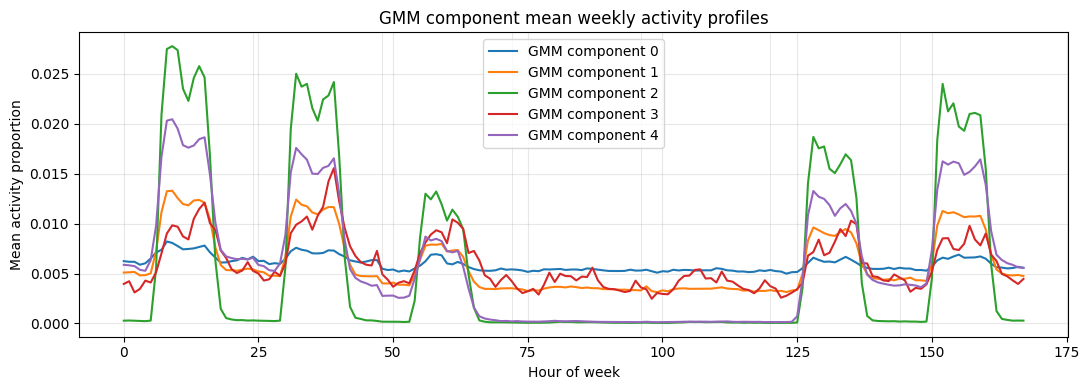

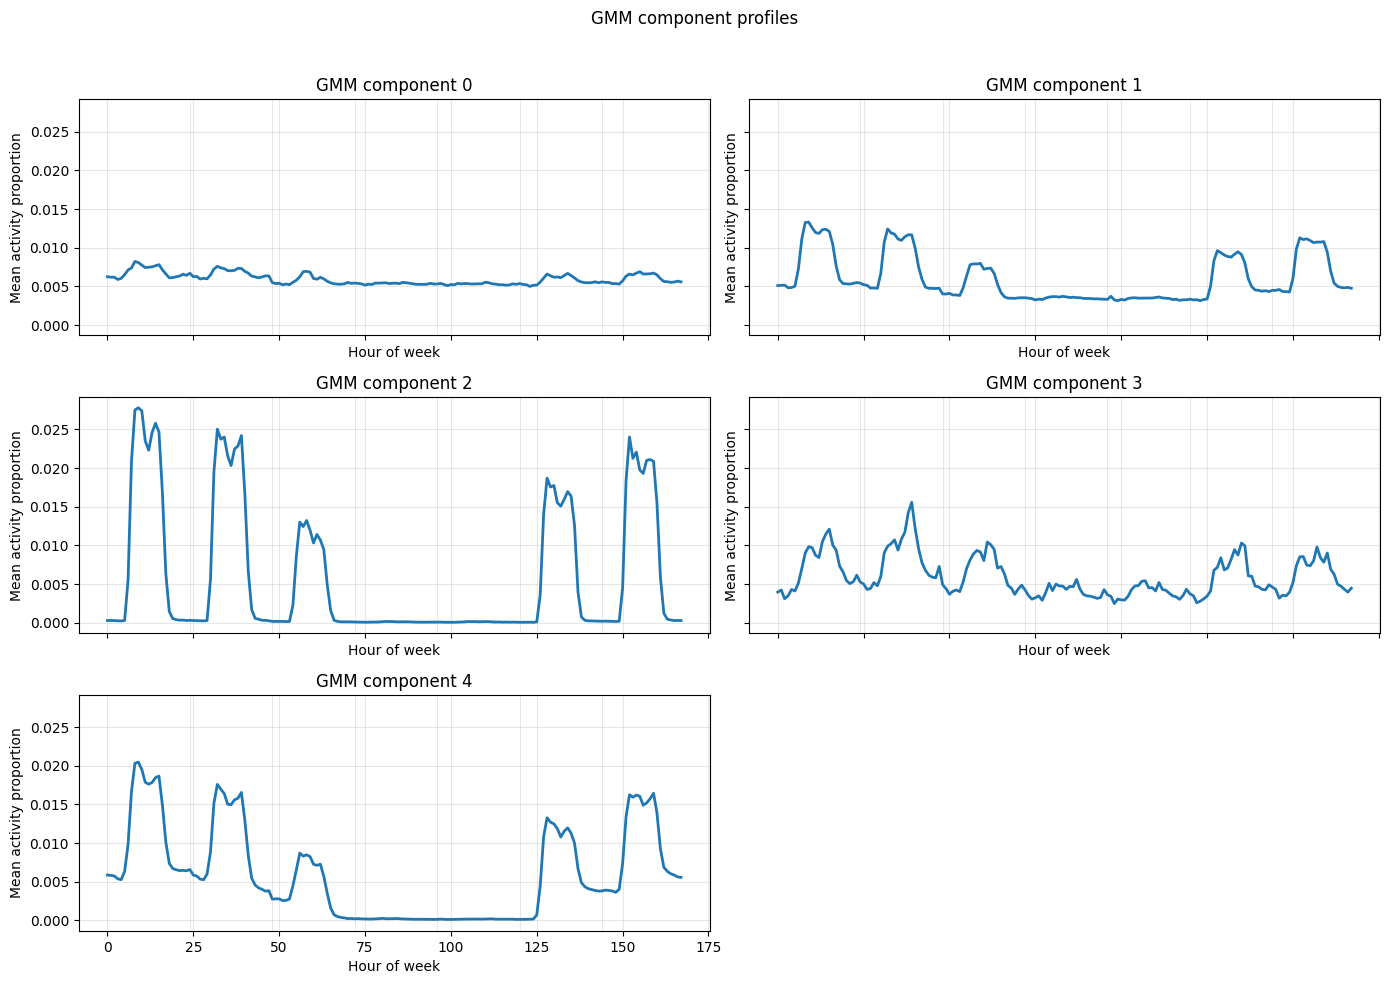

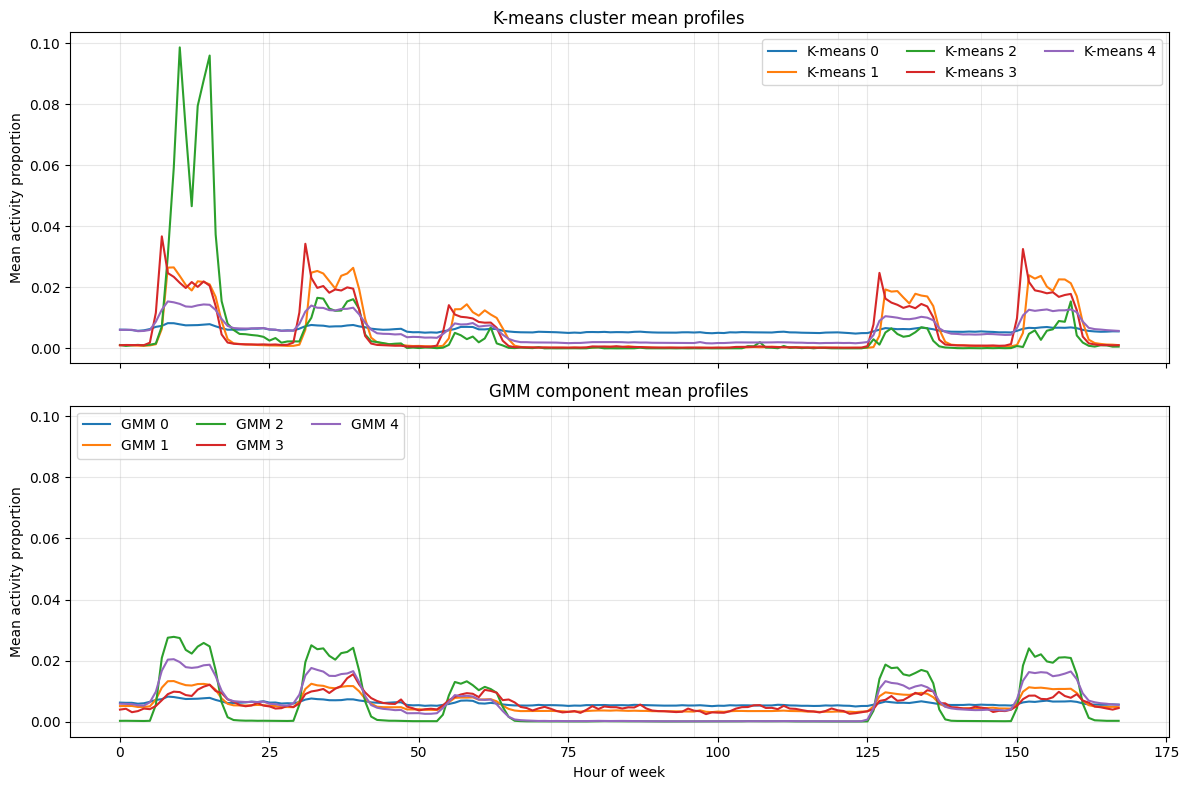


GMM posterior probabilities for U22@DOM1
hour_of_week source_user@domain type_str  kmeans_cluster  gmm_cluster  \
14630                  U22@DOM1    human               0            0   

hour_of_week  gmm_max_prob  gmm_second_prob  gmm_margin  
14630                  1.0     2.974553e-24         1.0  
   gmm_cluster  posterior_probability
0            0                    1.0
1            1                    0.0
3            3                    0.0
4            4                    0.0
2            2                    0.0

Saved useful objects:
- gmm
- gmm_labels
- gmm_probs
- gmm_members
- gmm_members_pl
- gmm_summary
- gmm_type_summary
- gmm_profile_prop
- kmeans_vs_gmm_counts
- kmeans_vs_gmm_rowshare
- gmm_confidence_summary


In [18]:
# ============================================================
# Diagonal-covariance GMM on weekly proportion profiles
# Compare against existing K-means clustering
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ============================================================
# Settings
# ============================================================

N_GMM_COMPONENTS = 5
RANDOM_STATE = 42

# X should already be the user × 168 weekly proportion matrix.
# No L2 normalisation should be applied.
assert "X" in globals(), "X not found. Run the clustering block first."
assert "profile_wide" in globals(), "profile_wide not found. Run the clustering block first."
assert "cluster_labels" in globals(), "cluster_labels not found. Run the K-means block first."

hour_cols = list(range(N_HOURS_WEEK))

# ============================================================
# 1. Fit GMM
# ============================================================

gmm = GaussianMixture(
    n_components=N_GMM_COMPONENTS,
    covariance_type="diag",
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=300,
    reg_covar=1e-6,
)

gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)

gmm_max_prob = gmm_probs.max(axis=1)
gmm_second_prob = np.sort(gmm_probs, axis=1)[:, -2]
gmm_margin = gmm_max_prob - gmm_second_prob

print("\nGMM converged:", gmm.converged_)
print("GMM iterations:", gmm.n_iter_)
print("GMM lower bound:", round(gmm.lower_bound_, 6))
print("GMM AIC:", round(gmm.aic(X), 2))
print("GMM BIC:", round(gmm.bic(X), 2))

# ============================================================
# 2. Build membership table
# ============================================================

gmm_members = (
    profile_wide
    .reset_index()[[USER_COL, "type_str"]]
    .assign(
        kmeans_cluster=cluster_labels,
        gmm_cluster=gmm_labels,
        gmm_max_prob=gmm_max_prob,
        gmm_second_prob=gmm_second_prob,
        gmm_margin=gmm_margin,
    )
)

gmm_members_pl = pl.from_pandas(gmm_members)

# ============================================================
# 3. Compare K-means and GMM labels
# ============================================================

ari = adjusted_rand_score(cluster_labels, gmm_labels)
nmi = normalized_mutual_info_score(cluster_labels, gmm_labels)

print("\nK-means vs GMM agreement")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalised Mutual Information: {nmi:.4f}")

kmeans_vs_gmm_counts = pd.crosstab(
    gmm_members["kmeans_cluster"],
    gmm_members["gmm_cluster"],
    rownames=["K-means cluster"],
    colnames=["GMM cluster"],
)

kmeans_vs_gmm_rowshare = pd.crosstab(
    gmm_members["kmeans_cluster"],
    gmm_members["gmm_cluster"],
    rownames=["K-means cluster"],
    colnames=["GMM cluster"],
    normalize="index",
)

print("\nK-means vs GMM counts")
print(kmeans_vs_gmm_counts)

print("\nK-means vs GMM row shares")
print(kmeans_vs_gmm_rowshare.round(3))

# ============================================================
# 4. Soft-assignment confidence
# ============================================================

gmm_confidence_summary = (
    gmm_members
    .groupby("gmm_cluster")
    .agg(
        n_accounts=("gmm_cluster", "count"),
        max_prob_q25=("gmm_max_prob", lambda x: x.quantile(0.25)),
        max_prob_median=("gmm_max_prob", "median"),
        max_prob_q75=("gmm_max_prob", lambda x: x.quantile(0.75)),
        margin_q25=("gmm_margin", lambda x: x.quantile(0.25)),
        margin_median=("gmm_margin", "median"),
        margin_q75=("gmm_margin", lambda x: x.quantile(0.75)),
    )
    .reset_index()
    .sort_values("gmm_cluster")
)

print("\nGMM soft-assignment confidence by GMM cluster")
print(gmm_confidence_summary.round(4))

print("\nLowest-confidence GMM assignments")
print(
    gmm_members
    .sort_values("gmm_margin")
    .head(20)[[USER_COL, "type_str", "kmeans_cluster", "gmm_cluster", "gmm_max_prob", "gmm_second_prob", "gmm_margin"]]
    .round(4)
)

# ============================================================
# 5. GMM summary by cluster and account type
# ============================================================

gmm_summary = (
    gmm_members_pl
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .group_by("gmm_cluster")
    .agg([
        pl.len().alias("n_accounts"),
        (pl.col("type_str") == "human").sum().alias("n_human"),
        (pl.col("type_str") == "machine").sum().alias("n_machine"),
        pl.col("n_events").sum().alias("n_events"),
        pl.col("n_events").median().alias("events_p50"),
        pl.col("n_events").quantile(0.90).alias("events_p90"),
        pl.col("gmm_max_prob").median().alias("gmm_prob_p50"),
        pl.col("gmm_margin").median().alias("gmm_margin_p50"),
    ])
    .with_columns([
        (pl.col("n_human") / pl.col("n_accounts")).alias("human_share"),
        (pl.col("n_machine") / pl.col("n_accounts")).alias("machine_share"),
        (pl.col("n_events") / pl.col("n_events").sum()).alias("event_share"),
    ])
    .sort("n_accounts", descending=True)
)

print("\nGMM cluster summary")
print(gmm_summary)

# ============================================================
# 6. GMM summary by cluster and account type
# ============================================================

gmm_type_summary = (
    gmm_members_pl
    .join(user_totals, on=[USER_COL, "type_str"], how="left")
    .group_by(["gmm_cluster", "type_str"])
    .agg([
        pl.len().alias("n_accounts"),
        pl.col("n_events").sum().alias("n_events"),
        pl.col("n_events").quantile(0.25).alias("events_q25"),
        pl.col("n_events").median().alias("events_p50"),
        pl.col("n_events").quantile(0.75).alias("events_q75"),
        pl.col("gmm_max_prob").median().alias("gmm_prob_p50"),
        pl.col("gmm_margin").median().alias("gmm_margin_p50"),
    ])
    .with_columns([
        (pl.col("events_q75") - pl.col("events_q25")).alias("events_iqr"),
    ])
    .sort(["gmm_cluster", "type_str"])
)

print("\nGMM cluster/type volume summary")
print(gmm_type_summary)

# ============================================================
# 7. Plot GMM component mean profiles
# ============================================================

gmm_profile_prop = pd.DataFrame(
    gmm.means_,
    index=range(N_GMM_COMPONENTS),
    columns=hour_cols,
)

print("\nGMM component profile sum check:")
print(gmm_profile_prop.sum(axis=1))

fig, ax = plt.subplots(figsize=(11, 4))

for comp in gmm_profile_prop.index:
    ax.plot(
        hour_cols,
        gmm_profile_prop.loc[comp],
        label=f"GMM component {comp}",
    )

ax.set_title("GMM component mean weekly activity profiles")
ax.set_xlabel("Hour of week")
ax.set_ylabel("Mean activity proportion")
ax.grid(True, alpha=0.3)

for x in range(24, N_HOURS_WEEK, 24):
    ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8. Small multiples: GMM component profiles
# ============================================================

n_cols = 2
n_rows = int(np.ceil(N_GMM_COMPONENTS / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.2 * n_rows),
    sharex=True,
    sharey=True,
)

axes = np.array(axes).reshape(-1)

for ax, comp in zip(axes, range(N_GMM_COMPONENTS)):
    ax.plot(hour_cols, gmm_profile_prop.loc[comp], linewidth=2)

    ax.set_title(f"GMM component {comp}")
    ax.set_xlabel("Hour of week")
    ax.set_ylabel("Mean activity proportion")
    ax.grid(True, alpha=0.3)

    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

for ax in axes[N_GMM_COMPONENTS:]:
    ax.axis("off")

fig.suptitle("GMM component profiles", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Compare K-means centroids and GMM means visually
# ============================================================

kmeans_profile_prop = (
    pd.DataFrame(X, index=profile_wide.index, columns=hour_cols)
    .assign(kmeans_cluster=cluster_labels)
    .groupby("kmeans_cluster")[hour_cols]
    .mean()
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

for cluster in kmeans_profile_prop.index:
    axes[0].plot(
        hour_cols,
        kmeans_profile_prop.loc[cluster],
        label=f"K-means {cluster}",
    )

axes[0].set_title("K-means cluster mean profiles")
axes[0].set_ylabel("Mean activity proportion")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3)

for comp in gmm_profile_prop.index:
    axes[1].plot(
        hour_cols,
        gmm_profile_prop.loc[comp],
        label=f"GMM {comp}",
    )

axes[1].set_title("GMM component mean profiles")
axes[1].set_xlabel("Hour of week")
axes[1].set_ylabel("Mean activity proportion")
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=3)

for ax in axes:
    for x in range(24, N_HOURS_WEEK, 24):
        ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# 10. Optional: inspect one user, e.g. U22@DOM1
# ============================================================

TARGET_USER = "U22@DOM1"

target_match = gmm_members[
    gmm_members[USER_COL].str.upper() == TARGET_USER.upper()
].copy()

if not target_match.empty:
    target_idx = target_match.index[0]

    target_probs = pd.DataFrame({
        "gmm_cluster": range(N_GMM_COMPONENTS),
        "posterior_probability": gmm_probs[target_idx],
    }).sort_values("posterior_probability", ascending=False)

    print(f"\nGMM posterior probabilities for {target_match.iloc[0][USER_COL]}")
    print(target_match[[USER_COL, "type_str", "kmeans_cluster", "gmm_cluster", "gmm_max_prob", "gmm_second_prob", "gmm_margin"]])
    print(target_probs.round(4))
else:
    print(f"\n{TARGET_USER} not found in gmm_members.")

# ============================================================
# Saved useful objects
# ============================================================

print("\nSaved useful objects:")
print("- gmm")
print("- gmm_labels")
print("- gmm_probs")
print("- gmm_members")
print("- gmm_members_pl")
print("- gmm_summary")
print("- gmm_type_summary")
print("- gmm_profile_prop")
print("- kmeans_vs_gmm_counts")
print("- kmeans_vs_gmm_rowshare")
print("- gmm_confidence_summary")


K-means vs GMM counts
gmm_cluster         0     1     2    3     4
kmeans_cluster                              
0               10038  1907     5  568     4
1                   0   117  1538  153   684
2                   0     0   120   22    42
3                   0   163  1335   78   626
4                  15  3000    15  266  1720

K-means vs GMM row shares
gmm_cluster         0      1      2      3      4
kmeans_cluster                                   
0               0.802  0.152  0.000  0.045  0.000
1               0.000  0.047  0.617  0.061  0.274
2               0.000  0.000  0.652  0.120  0.228
3               0.000  0.074  0.606  0.035  0.284
4               0.003  0.598  0.003  0.053  0.343

K-means cluster 2 size: 184

GMM assignment distribution for K-means spiky cluster
gmm_cluster
2    120
3     22
4     42
Name: n_accounts, dtype: int64

GMM confidence for K-means spiky cluster
hour_of_week  gmm_max_prob  gmm_second_prob  gmm_margin
count             184.0000       

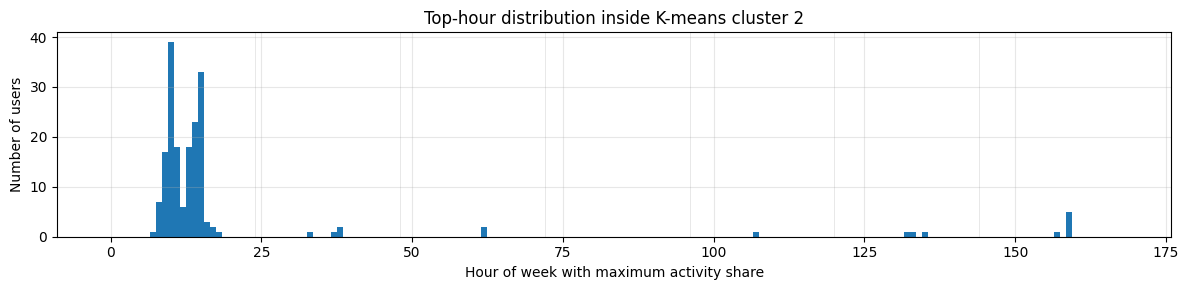


GMM variance summary
   gmm_cluster    weight  mean_top1  mean_top10  avg_variance  \
0            0  0.448486   0.008213    0.076884      0.000004   
1            1  0.231303   0.013299    0.124013      0.000018   
4            4  0.137351   0.020459    0.185261      0.000074   
2            2  0.134375   0.027783    0.254921      0.000265   
3            3  0.048485   0.015561    0.119650      0.000285   

   median_variance  variance_top10_mean_hours  max_variance  
0         0.000003                   0.000008      0.000013  
1         0.000011                   0.000048      0.000077  
4         0.000031                   0.000277      0.000423  
2         0.000002                   0.001380      0.001818  
3         0.000200                   0.000893      0.001518  

GMM component summaries for different k
    gmm_cluster  n_accounts  n_from_kmeans_spiky  median_prob  \
2             2        3013                  120          1.0   
3             3        1087                 

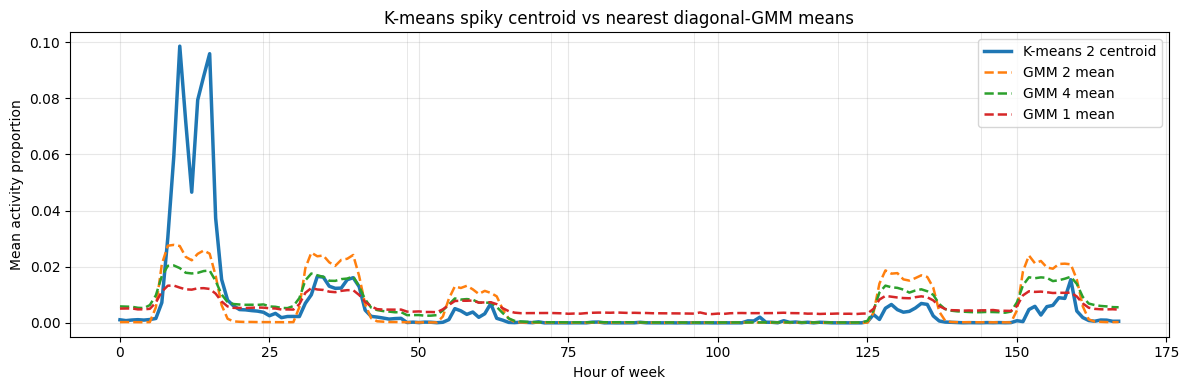

In [19]:
# ============================================================
# Investigate why diagonal GMM does not isolate K-means spiky cluster 2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import pairwise_distances

# Required existing objects:
# X, cluster_labels, gmm, gmm_labels, gmm_probs, profile_wide, USER_COL, N_HOURS_WEEK

KMEANS_SPIKY_CLUSTER = 2
RANDOM_STATE = 42
hour_cols = list(range(N_HOURS_WEEK))

# ============================================================
# 1. How did GMM assign the K-means spiky users?
# ============================================================

comparison_df = (
    profile_wide
    .reset_index()[[USER_COL, "type_str"]]
    .assign(
        kmeans_cluster=cluster_labels,
        gmm_cluster=gmm_labels,
        gmm_max_prob=gmm_probs.max(axis=1),
        gmm_second_prob=np.sort(gmm_probs, axis=1)[:, -2],
    )
)

comparison_df["gmm_margin"] = (
    comparison_df["gmm_max_prob"] - comparison_df["gmm_second_prob"]
)

print("\nK-means vs GMM counts")
print(pd.crosstab(comparison_df["kmeans_cluster"], comparison_df["gmm_cluster"]))

print("\nK-means vs GMM row shares")
print(
    pd.crosstab(
        comparison_df["kmeans_cluster"],
        comparison_df["gmm_cluster"],
        normalize="index"
    ).round(3)
)

spiky_members = comparison_df[
    comparison_df["kmeans_cluster"] == KMEANS_SPIKY_CLUSTER
].copy()

print(f"\nK-means cluster {KMEANS_SPIKY_CLUSTER} size:", len(spiky_members))

print("\nGMM assignment distribution for K-means spiky cluster")
print(
    spiky_members["gmm_cluster"]
    .value_counts()
    .sort_index()
    .rename("n_accounts")
)

print("\nGMM confidence for K-means spiky cluster")
print(
    spiky_members[["gmm_max_prob", "gmm_second_prob", "gmm_margin"]]
    .describe()
    .round(4)
)

# ============================================================
# 2. Compare K-means spiky centroid to all GMM means
# ============================================================

kmeans_centroids = (
    pd.DataFrame(X, index=profile_wide.index, columns=hour_cols)
    .assign(kmeans_cluster=cluster_labels)
    .groupby("kmeans_cluster")[hour_cols]
    .mean()
)

gmm_means = pd.DataFrame(
    gmm.means_,
    index=range(gmm.n_components),
    columns=hour_cols,
)

spiky_kmeans_centroid = kmeans_centroids.loc[KMEANS_SPIKY_CLUSTER].to_numpy().reshape(1, -1)

dist_to_gmm = pd.DataFrame({
    "gmm_cluster": range(gmm.n_components),
    "euclidean_distance": pairwise_distances(spiky_kmeans_centroid, gmm.means_, metric="euclidean").flatten(),
    "tv_distance": pairwise_distances(spiky_kmeans_centroid, gmm.means_, metric="manhattan").flatten() / 2,
    "gmm_weight": gmm.weights_,
    "gmm_mean_top1": gmm.means_.max(axis=1),
    "gmm_mean_top10": np.sort(gmm.means_, axis=1)[:, -10:].sum(axis=1),
}).sort_values("euclidean_distance")

print("\nDistance from K-means spiky centroid to GMM means")
print(dist_to_gmm.round(4))

# ============================================================
# 3. Is the K-means spiky cluster internally aligned or heterogeneous?
# ============================================================

spiky_idx = np.where(cluster_labels == KMEANS_SPIKY_CLUSTER)[0]
X_spiky = X[spiky_idx]

spiky_top_hour = X_spiky.argmax(axis=1)
spiky_top_share = X_spiky.max(axis=1)
spiky_top10_share = np.sort(X_spiky, axis=1)[:, -10:].sum(axis=1)
spiky_coverage = (X_spiky > 0).sum(axis=1) / N_HOURS_WEEK

spiky_shape_summary = pd.DataFrame({
    "top_hour": spiky_top_hour,
    "top1_share": spiky_top_share,
    "top10_share": spiky_top10_share,
    "coverage_168": spiky_coverage,
})

print("\nK-means spiky cluster shape summary")
print(spiky_shape_summary[["top1_share", "top10_share", "coverage_168"]].describe().round(4))

print("\nMost common top hours in K-means spiky cluster")
print(
    spiky_shape_summary["top_hour"]
    .value_counts()
    .head(20)
    .rename_axis("hour_of_week")
    .reset_index(name="n_users")
)

# Plot top-hour distribution
fig, ax = plt.subplots(figsize=(12, 3))
ax.hist(spiky_top_hour, bins=np.arange(0, N_HOURS_WEEK + 1) - 0.5)
ax.set_title(f"Top-hour distribution inside K-means cluster {KMEANS_SPIKY_CLUSTER}")
ax.set_xlabel("Hour of week with maximum activity share")
ax.set_ylabel("Number of users")
ax.grid(True, alpha=0.3)

for x in range(24, N_HOURS_WEEK, 24):
    ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Are GMM variances too broad around the spiky hours?
# ============================================================

# For each GMM component, inspect average diagonal variance and variance at its top mean hours
gmm_var_summary = []

for comp in range(gmm.n_components):
    mean_profile = gmm.means_[comp]
    var_profile = gmm.covariances_[comp]

    top_hours = np.argsort(mean_profile)[-10:]

    gmm_var_summary.append({
        "gmm_cluster": comp,
        "weight": gmm.weights_[comp],
        "mean_top1": mean_profile.max(),
        "mean_top10": np.sort(mean_profile)[-10:].sum(),
        "avg_variance": var_profile.mean(),
        "median_variance": np.median(var_profile),
        "variance_top10_mean_hours": var_profile[top_hours].mean(),
        "max_variance": var_profile.max(),
    })

gmm_var_summary = pd.DataFrame(gmm_var_summary).sort_values("weight", ascending=False)

print("\nGMM variance summary")
print(gmm_var_summary.round(6))

# ============================================================
# 5. Refit GMM with more components: does a spiky component emerge?
# ============================================================

gmm_k_results = []

for k in [5, 6, 8, 10]:
    test_gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300,
        reg_covar=1e-6,
    )

    test_labels = test_gmm.fit_predict(X)
    test_probs = test_gmm.predict_proba(X)

    component_top1 = test_gmm.means_.max(axis=1)
    component_top10 = np.sort(test_gmm.means_, axis=1)[:, -10:].sum(axis=1)

    # For each component, what fraction came from K-means spiky cluster?
    tmp = pd.DataFrame({
        "kmeans_cluster": cluster_labels,
        "gmm_cluster": test_labels,
        "max_prob": test_probs.max(axis=1),
    })

    comp_summary = (
        tmp
        .groupby("gmm_cluster")
        .agg(
            n_accounts=("gmm_cluster", "count"),
            n_from_kmeans_spiky=("kmeans_cluster", lambda s: (s == KMEANS_SPIKY_CLUSTER).sum()),
            median_prob=("max_prob", "median"),
        )
        .reset_index()
    )

    comp_summary["share_from_kmeans_spiky"] = (
        comp_summary["n_from_kmeans_spiky"] / comp_summary["n_accounts"]
    )

    comp_summary["gmm_k"] = k
    comp_summary["component_top1"] = component_top1[comp_summary["gmm_cluster"].to_numpy()]
    comp_summary["component_top10"] = component_top10[comp_summary["gmm_cluster"].to_numpy()]

    gmm_k_results.append(comp_summary)

gmm_k_results = pd.concat(gmm_k_results, ignore_index=True)

print("\nGMM component summaries for different k")
print(
    gmm_k_results
    .sort_values(["gmm_k", "share_from_kmeans_spiky"], ascending=[True, False])
    .round(4)
)

print("\nBest spiky-capturing component at each k")
best_spiky_components = (
    gmm_k_results
    .sort_values(["gmm_k", "share_from_kmeans_spiky"], ascending=[True, False])
    .groupby("gmm_k")
    .head(1)
)

print(best_spiky_components.round(4))

# ============================================================
# 6. Initialise GMM means at K-means centroids
#    Does that preserve the spiky component?
# ============================================================

gmm_from_kmeans = GaussianMixture(
    n_components=len(np.unique(cluster_labels)),
    covariance_type="diag",
    random_state=RANDOM_STATE,
    n_init=1,
    max_iter=300,
    reg_covar=1e-6,
    means_init=kmeans_centroids.sort_index().to_numpy(),
)

gmm_from_kmeans_labels = gmm_from_kmeans.fit_predict(X)

print("\nGMM initialised from K-means centroids")
print("Converged:", gmm_from_kmeans.converged_)
print("Iterations:", gmm_from_kmeans.n_iter_)
print("ARI vs K-means:", round(adjusted_rand_score(cluster_labels, gmm_from_kmeans_labels), 4))
print("NMI vs K-means:", round(normalized_mutual_info_score(cluster_labels, gmm_from_kmeans_labels), 4))

print("\nK-means vs GMM-from-K-means counts")
print(pd.crosstab(cluster_labels, gmm_from_kmeans_labels))

gmm_from_kmeans_means = pd.DataFrame(
    gmm_from_kmeans.means_,
    index=range(gmm_from_kmeans.n_components),
    columns=hour_cols,
)

print("\nGMM-from-K-means component spike summary")
print(
    pd.DataFrame({
        "component": range(gmm_from_kmeans.n_components),
        "weight": gmm_from_kmeans.weights_,
        "mean_top1": gmm_from_kmeans.means_.max(axis=1),
        "mean_top10": np.sort(gmm_from_kmeans.means_, axis=1)[:, -10:].sum(axis=1),
    }).round(4)
)

# ============================================================
# 7. Visual comparison: K-means spiky centroid vs nearest GMM means
# ============================================================

nearest_gmm_components = dist_to_gmm["gmm_cluster"].head(3).tolist()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    hour_cols,
    kmeans_centroids.loc[KMEANS_SPIKY_CLUSTER],
    linewidth=2.5,
    label=f"K-means {KMEANS_SPIKY_CLUSTER} centroid",
)

for comp in nearest_gmm_components:
    ax.plot(
        hour_cols,
        gmm_means.loc[comp],
        linestyle="--",
        linewidth=1.8,
        label=f"GMM {comp} mean",
    )

ax.set_title("K-means spiky centroid vs nearest diagonal-GMM means")
ax.set_xlabel("Hour of week")
ax.set_ylabel("Mean activity proportion")
ax.grid(True, alpha=0.3)

for x in range(24, N_HOURS_WEEK, 24):
    ax.axvline(x, color="grey", linewidth=0.5, alpha=0.25)

ax.legend()
plt.tight_layout()
plt.show()